In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [18]:
df = pd.read_csv("grid_search_results_final.csv")
df["is_gru"] = df["unit_type"].apply(lambda x: 1 if x == "GRU" else 0)
df

,config_idx,config_name,n_ae_layers,n_header_layers,unit_type,mask_percent,activation,loss,optimizer,learning_rate,batch_size,epochs_ae,epochs_header,test_mae,final_ae_loss,final_header_loss,status,is_gru
0,19,ae2_hd2_gru_m20_tanh_adam_lr0.001_bs64_mae,2,2,GRU,0.2,tanh,mae,adam,0.0010,64,10,15,0.001712,0.009007,0.001818,success,1
1,7,ae2_hd1_gru_m20_tanh_adam_lr0.001_bs64_mae,2,1,GRU,0.2,tanh,mae,adam,0.0010,64,10,15,0.002029,0.010031,0.002832,success,1
2,43,ae3_hd2_gru_m20_tanh_adam_lr0.001_bs64_mae,3,2,GRU,0.2,tanh,mae,adam,0.0010,64,10,15,0.002410,0.011706,0.002410,success,1
3,21,ae2_hd2_gru_m50_tanh_adam_lr0.001_bs64_mae,2,2,GRU,0.5,tanh,mae,adam,0.0010,64,10,15,0.002620,0.010641,0.002620,success,1
4,9,ae2_hd1_gru_m50_tanh_adam_lr0.001_bs64_mae,2,1,GRU,0.5,tanh,mae,adam,0.0010,64,10,15,0.003048,0.010284,0.003419,success,1
5,31,ae3_hd1_gru_m20_tanh_adam_lr0.001_bs64_mae,3,1,GRU,0.2,tanh,mae,adam,0.0010,64,10,15,0.003096,0.010820,0.003096,success,1
6,45,ae3_hd2_gru_m50_tanh_adam_lr0.001_bs64_mae,3,2,GRU,0.5,tanh,mae,adam,0.0010,64,10,15,0.003402,0.011520,0.003402,success,1
7,8,ae2_hd1_gru_m20_tanh_adam_lr0.0001_bs64_mae,2,1,GRU,0.2,tanh,mae,adam,0.0001,64,10,15,0.004139,0.019697,0.004139,success,1
8,22,ae2_hd2_gru_m50_tanh_adam_lr0.0001_bs64_mae,2,2,GRU,0.5,tanh,mae,adam,0.0001,64,10,15,0.004547,0.023829,0.004547,success,1
9,33,ae3_hd1_gru_m50_tanh_adam_lr0.001_bs64_mae,3,1,GRU,0.5,tanh,mae,adam,0.0010,64,10,15,0.004937,0.011127,0.004937,success,1


In [19]:
df.columns

Index(['config_idx', 'config_name', 'n_ae_layers', 'n_header_layers',
       'unit_type', 'mask_percent', 'activation', 'loss', 'optimizer',
       'learning_rate', 'batch_size', 'epochs_ae', 'epochs_header', 'test_mae',
       'final_ae_loss', 'final_header_loss', 'status', 'is_gru'],
      dtype='object')

In [20]:
independant_variables = [
    'n_ae_layers', 'n_header_layers', 'is_gru', 'mask_percent', 'learning_rate'
]

dependant_variables = [
    'test_mae', 'final_ae_loss', 'final_header_loss'
]

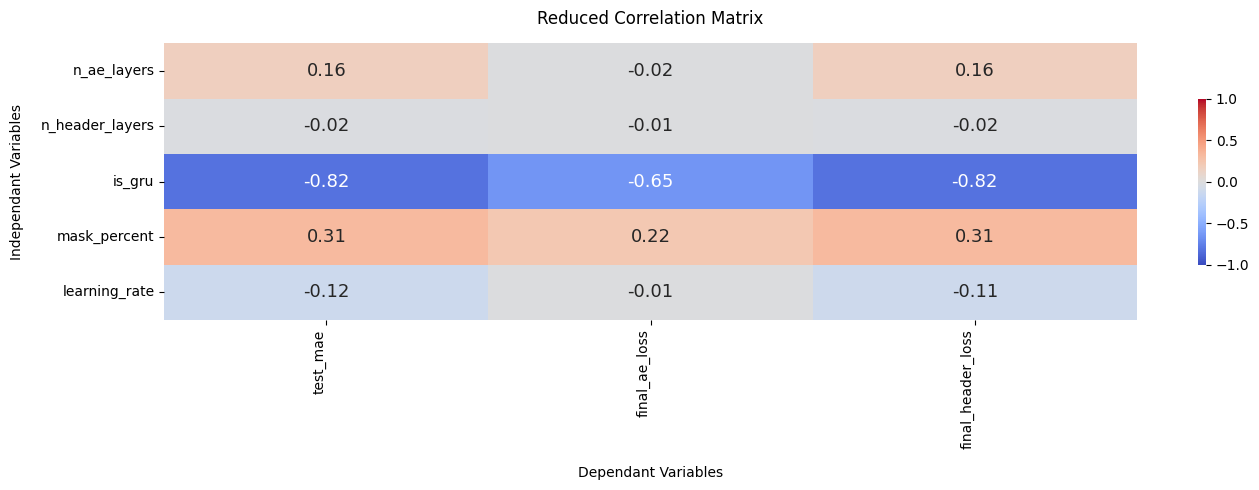

In [21]:
set_bottom = dependant_variables
set_right = independant_variables

A = df[set_right].values
B = df[set_bottom].values

corr = np.corrcoef(A.T, B.T)
corr_mat = corr[:len(set_right), len(set_right):]

corr_df = pd.DataFrame(corr_mat, index=set_right, columns=set_bottom)

# Create figure and axes
fig, ax = plt.subplots(figsize=(14, 5))   # wider figure to fit long x-labels

# Plot heatmap
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    ax=ax,
    cbar_kws={"shrink": 0.6},
    annot_kws={"fontsize": 13}              # reduce annotation font size if crowded
)

# Tweak tick labels so they don't get cut off
ax.set_xlabel("Dependant Variables", labelpad=12)
ax.set_ylabel("Independant Variables", labelpad=12)
ax.set_title("Reduced Correlation Matrix", pad=14)

# Rotate and right-align x tick labels (long names)
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)

# Optionally reduce x tick label font size if still crowded
for tick in ax.get_xticklabels():
    tick.set_fontsize(10)

# Tight layout and save without clipping
plt.tight_layout()
plt.savefig("reduced_corr_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

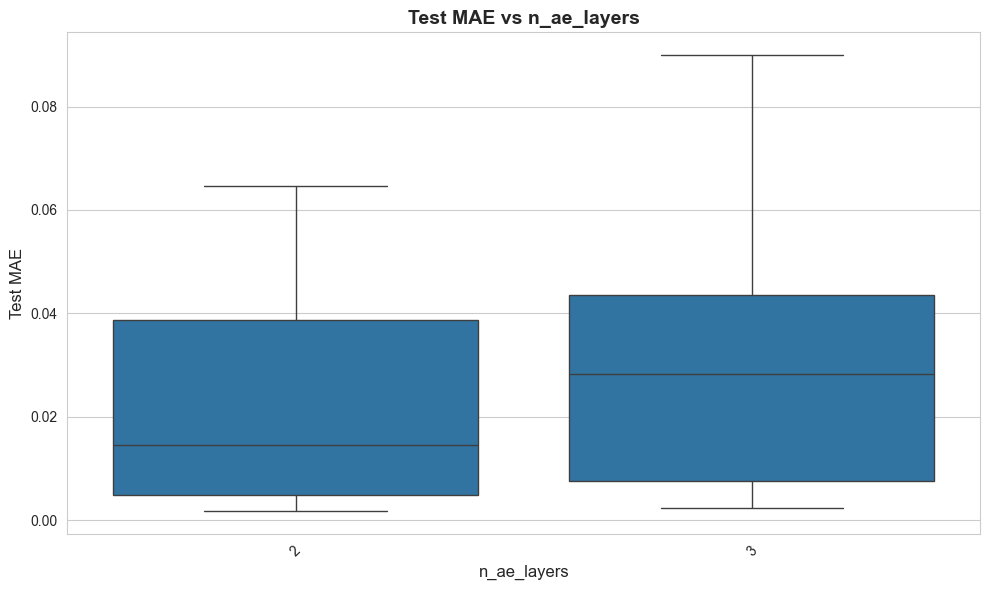

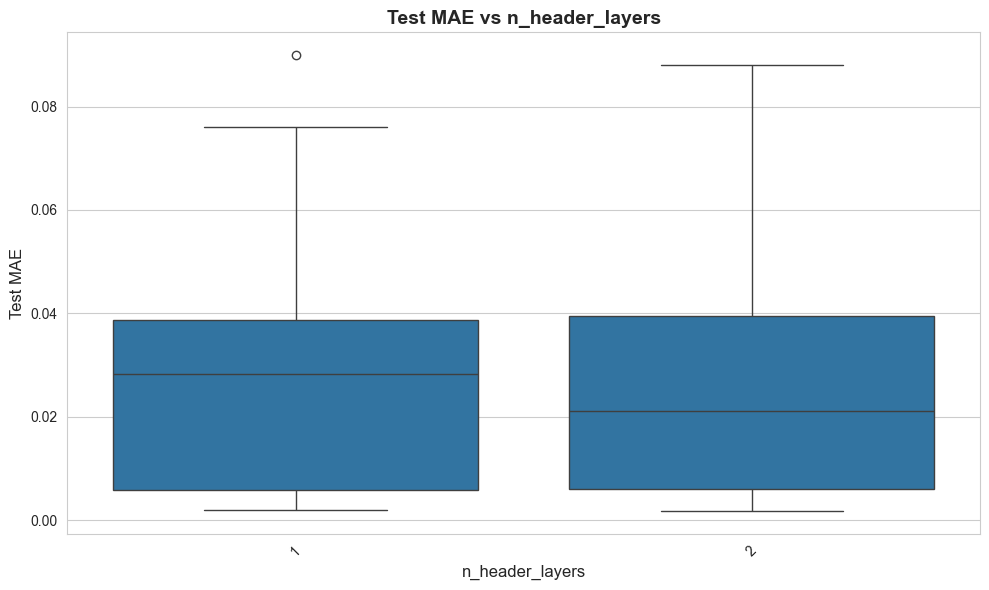

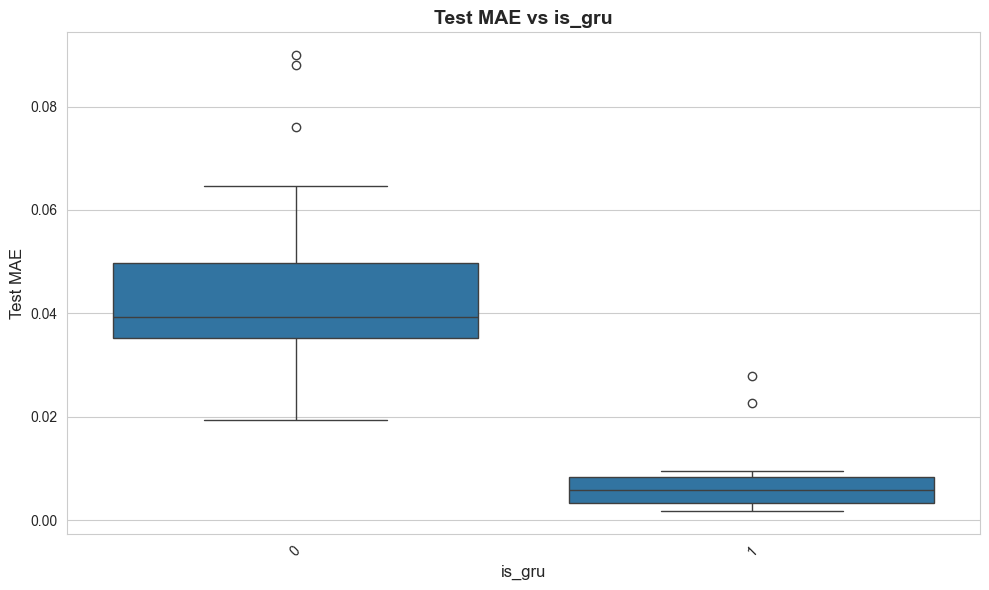

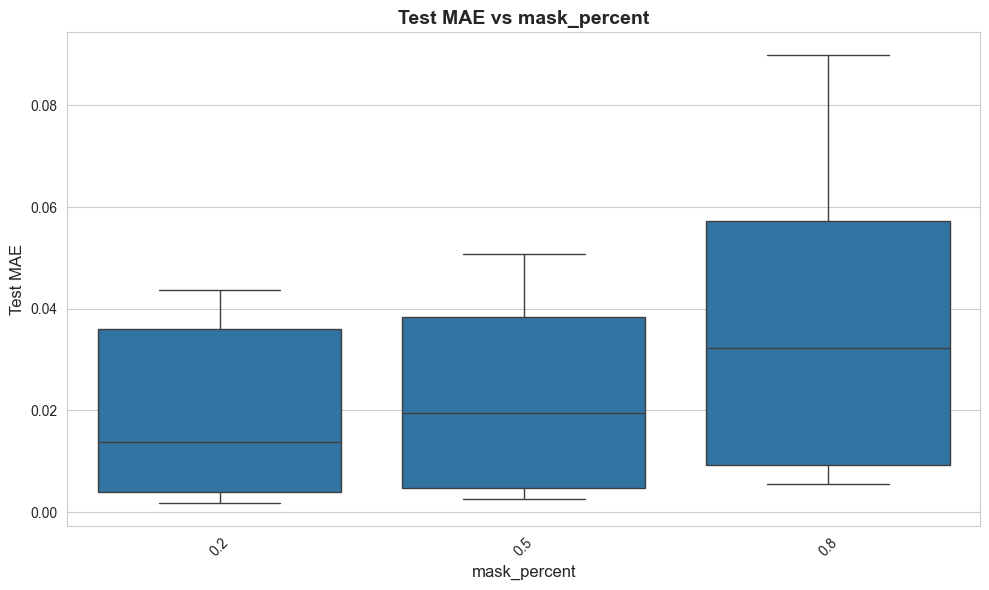

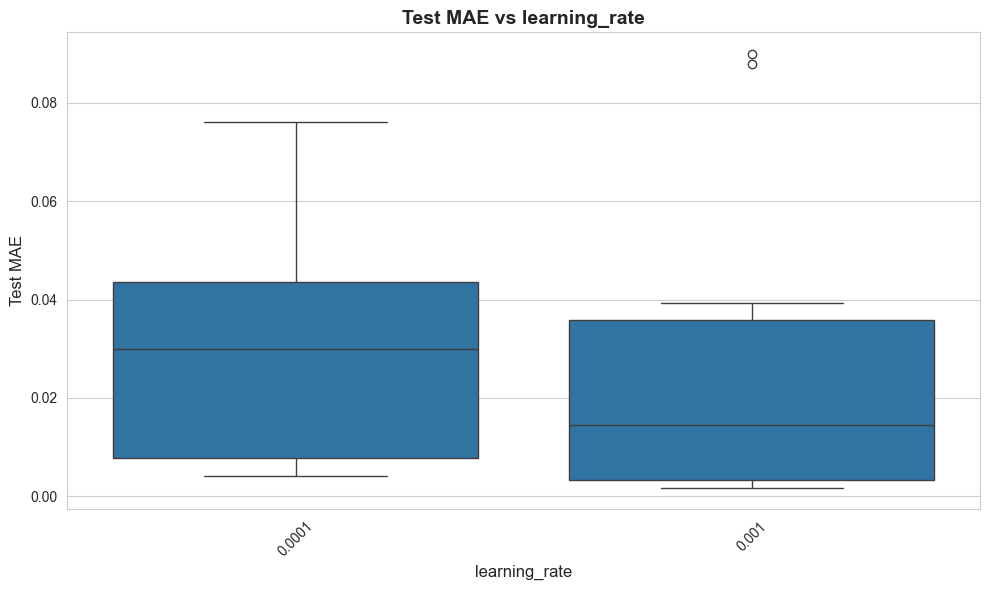

In [24]:
sns.set_style("whitegrid")

for var in independant_variables:
    plt.figure(figsize=(10, 6))
    
    n_unique = df[var].nunique()
    
    if n_unique <= 10:  # Categorical or few unique values
        sns.boxplot(data=df, x=var, y='test_mae')
    else:  # Continuous variable
        sns.scatterplot(data=df, x=var, y='test_mae', alpha=0.6)
        # Add a trend line
        sns.regplot(data=df, x=var, y='test_mae', scatter=False, color='red')
    
    plt.title(f'Test MAE vs {var}', fontsize=14, fontweight='bold')
    plt.xlabel(var, fontsize=12)
    plt.ylabel('Test MAE', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()